Training Accuracy: 0.9899497487437185
Training Precision: 0.9899497487437185
Training Recall: 0.9899497487437185
Training F1: 0.9899497487437185
Test Accuracy: 0.64
Test Precision: 0.6285714285714286
Test Recall: 0.64
Test F1: 0.6245989304812835
Test ROC-AUC: None
Test Log Loss: None
Train-Test Gap: 0.34994974874371854


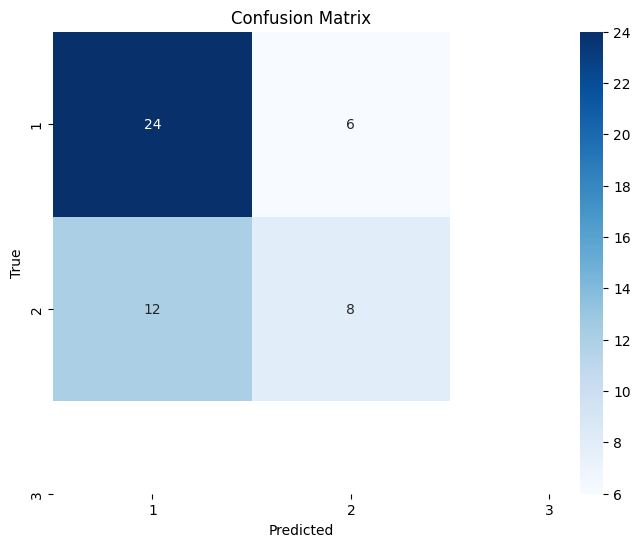

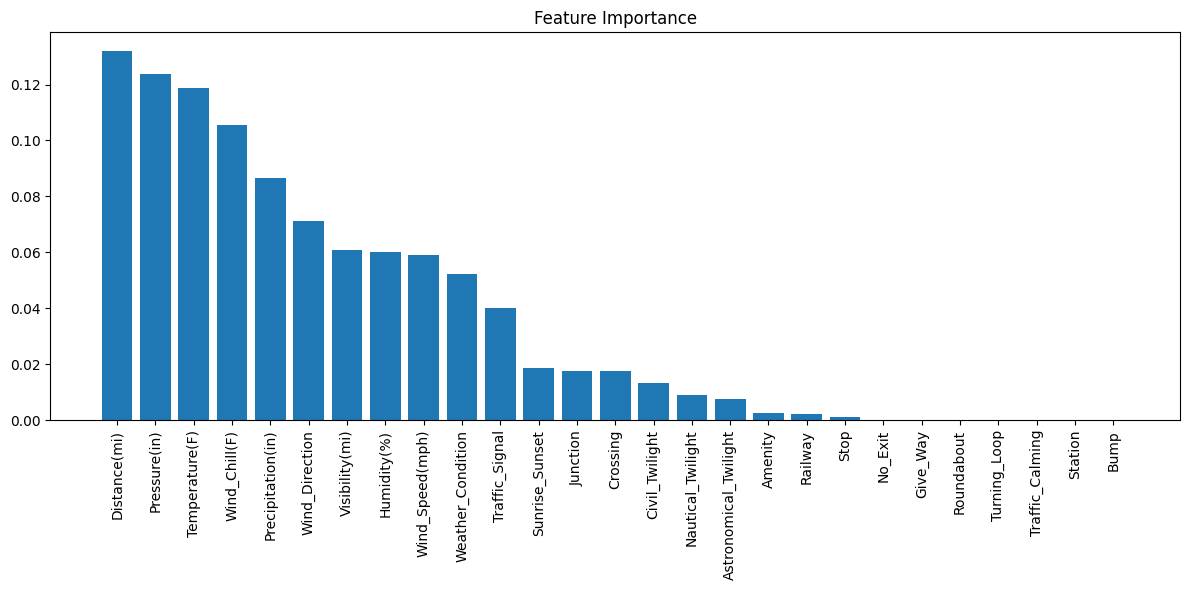

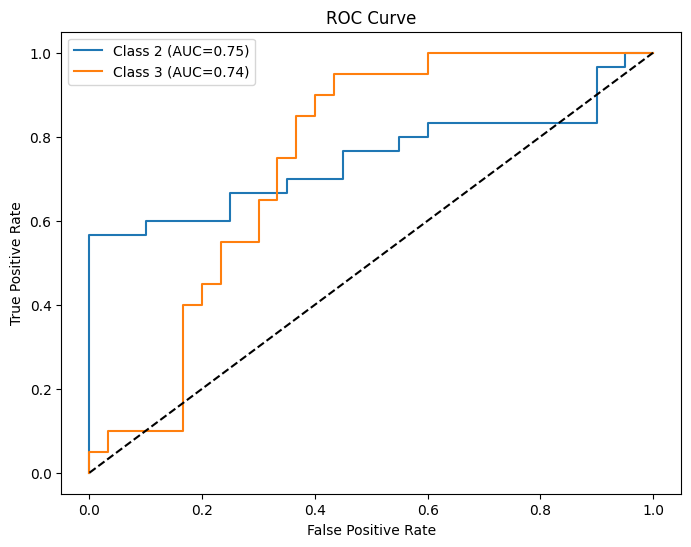

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


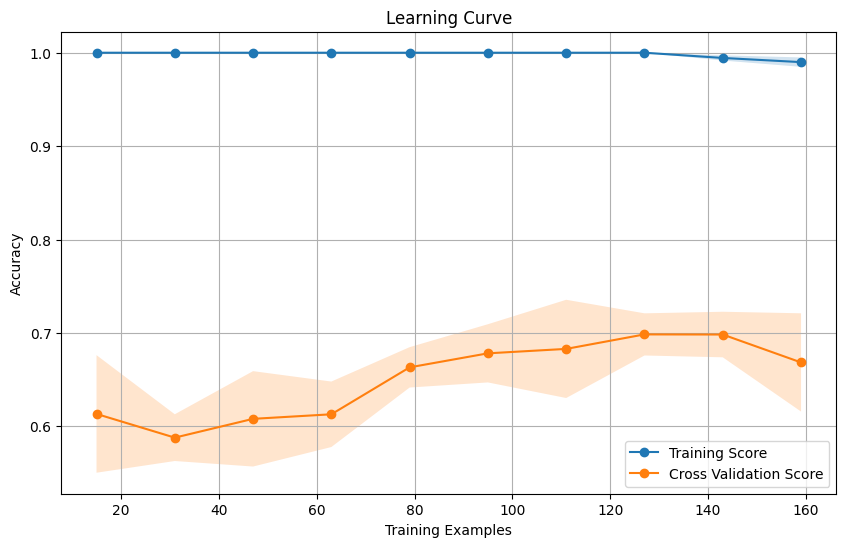

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    confusion_matrix,
    roc_curve,
    auc
)

df = pd.read_csv("US A 10000.csv")

keep_cols = [
    "Severity", "Distance(mi)", "Temperature(F)", "Wind_Chill(F)",
    "Humidity(%)", "Pressure(in)", "Visibility(mi)", "Wind_Speed(mph)",
    "Precipitation(in)", "Wind_Direction", "Weather_Condition",
    "Sunrise_Sunset", "Civil_Twilight", "Nautical_Twilight",
    "Astronomical_Twilight", "Amenity", "Bump", "Crossing",
    "Give_Way", "Junction", "No_Exit", "Railway",
    "Roundabout", "Station", "Stop", "Traffic_Calming",
    "Traffic_Signal", "Turning_Loop"
]

df = df[keep_cols].dropna().copy()

categorical_cols = [
    "Wind_Direction", "Weather_Condition", "Sunrise_Sunset",
    "Civil_Twilight", "Nautical_Twilight", "Astronomical_Twilight",
    "Amenity", "Bump", "Crossing", "Give_Way", "Junction",
    "No_Exit", "Railway", "Roundabout", "Station", "Stop",
    "Traffic_Calming", "Traffic_Signal", "Turning_Loop"
]

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

X = df.drop("Severity", axis=1)
y = df["Severity"]

numeric_cols = [
    "Distance(mi)", "Temperature(F)", "Wind_Chill(F)",
    "Humidity(%)", "Pressure(in)", "Visibility(mi)",
    "Wind_Speed(mph)", "Precipitation(in)"
]

class_counts = y.value_counts()

if class_counts.min() >= 2:
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)
y_test_proba = rf.predict_proba(X_test)

def evaluate(y_true, y_pred, y_proba=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    roc_auc = None
    logloss = None

    if y_proba is not None:
        try:
            roc_auc = roc_auc_score(
                y_true,
                y_proba,
                multi_class="ovr",
                average="weighted"
            )
        except:
            pass

        try:
            logloss = log_loss(y_true, y_proba)
        except:
            pass

    return acc, prec, rec, f1, roc_auc, logloss

train_acc, train_prec, train_rec, train_f1, _, _ = evaluate(
    y_train,
    y_train_pred
)

test_acc, test_prec, test_rec, test_f1, test_roc_auc, test_logloss = evaluate(
    y_test,
    y_test_pred,
    y_test_proba
)

print("Training Accuracy:", train_acc)
print("Training Precision:", train_prec)
print("Training Recall:", train_rec)
print("Training F1:", train_f1)

print("Test Accuracy:", test_acc)
print("Test Precision:", test_prec)
print("Test Recall:", test_rec)
print("Test F1:", test_f1)
print("Test ROC-AUC:", test_roc_auc)
print("Test Log Loss:", test_logloss)

print("Train-Test Gap:", train_acc - test_acc)

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=rf.classes_,
    yticklabels=rf.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), X.columns[indices], rotation=90)
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

classes = rf.classes_

y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8, 6))

for i in range(len(classes)):
    if np.unique(y_test_bin[:, i]).size > 1:
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
        roc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {classes[i]} (AUC={roc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

train_sizes, train_scores, test_scores = learning_curve(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, "o-", label="Training Score")
plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.plot(train_sizes, test_mean, "o-", label="Cross Validation Score")
plt.fill_between(
    train_sizes,
    test_mean - test_std,
    test_mean + test_std,
    alpha=0.2
)

plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.grid(True)
plt.legend()
plt.show()